<a href="https://colab.research.google.com/github/Somya456/Image-Segmentation-for-Disaster-Resilience/blob/main/Model_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import load_model
import tensorflow.keras.backend as K

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
DATASET_PATH = "/content/drive/MyDrive/Infyntrek DS&ML Group 1 - Task 3"

X_test = np.load(os.path.join(DATASET_PATH, "X_test.npy"))
Y_test = np.load(os.path.join(DATASET_PATH, "Y_test.npy"))

Y_test = Y_test.astype(np.float32)

print(X_test.shape)
print(Y_test.shape)

(341, 256, 256, 3)
(341, 256, 256, 1)


In [6]:
def dice_coefficient(y_true, y_pred):

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    smooth = 1e-6

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)

    return (
        2. * intersection + smooth
    ) / (
        K.sum(y_true_f)
        + K.sum(y_pred_f)
        + smooth
    )


def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)


def iou_score(y_true, y_pred):

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    smooth = 1e-6

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)

    union = (
        K.sum(y_true_f)
        + K.sum(y_pred_f)
        - intersection
    )

    return (intersection + smooth) / (union + smooth)


bce = tf.keras.losses.BinaryCrossentropy()

def combined_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)

In [9]:
cnn_model = load_model(

    os.path.join(DATASET_PATH, "basic_cnn_final.keras"),

    custom_objects={
        "combined_loss": combined_loss,
        "dice_coefficient": dice_coefficient,
        "iou_score": iou_score
    }
)

unet_model = load_model(

    os.path.join(DATASET_PATH, "enhanced_unet_final.keras"),

    custom_objects={
        "combined_loss": combined_loss,
        "dice_coefficient": dice_coefficient,
        "iou_score": iou_score
    }
)

print("Both models loaded successfully.")

Both models loaded successfully.


In [10]:
cnn_results = cnn_model.evaluate(
    X_test,
    Y_test,
    verbose=0,
    return_dict=True
)

unet_results = unet_model.evaluate(
    X_test,
    Y_test,
    verbose=0,
    return_dict=True
)

In [11]:
import pandas as pd

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Dice",
        "IoU",
        "Loss"
    ],

    "Basic CNN":[
        cnn_results["accuracy"],
        cnn_results["dice_coefficient"],
        cnn_results["iou_score"],
        cnn_results["loss"]
    ],

    "Enhanced U-Net":[
        unet_results["accuracy"],
        unet_results["dice_coefficient"],
        unet_results["iou_score"],
        unet_results["loss"]
    ]

})

comparison

print(comparison.round(4))

     Metric  Basic CNN  Enhanced U-Net
0  Accuracy     0.8928          0.9233
1      Dice     0.8356          0.8774
2       IoU     0.7178          0.7817
3      Loss     0.4411          0.3279


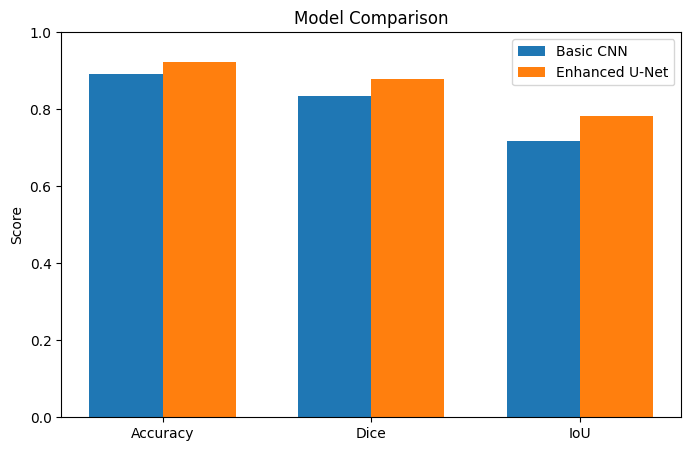

In [12]:
metrics = ["accuracy", "dice_coefficient", "iou_score"]

cnn = [
    cnn_results["accuracy"],
    cnn_results["dice_coefficient"],
    cnn_results["iou_score"]
]

unet = [
    unet_results["accuracy"],
    unet_results["dice_coefficient"],
    unet_results["iou_score"]
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x-width/2,
    cnn,
    width,
    label="Basic CNN"
)

plt.bar(
    x+width/2,
    unet,
    width,
    label="Enhanced U-Net"
)

plt.xticks(
    x,
    ["Accuracy","Dice","IoU"]
)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Model Comparison")

plt.legend()

plt.show()

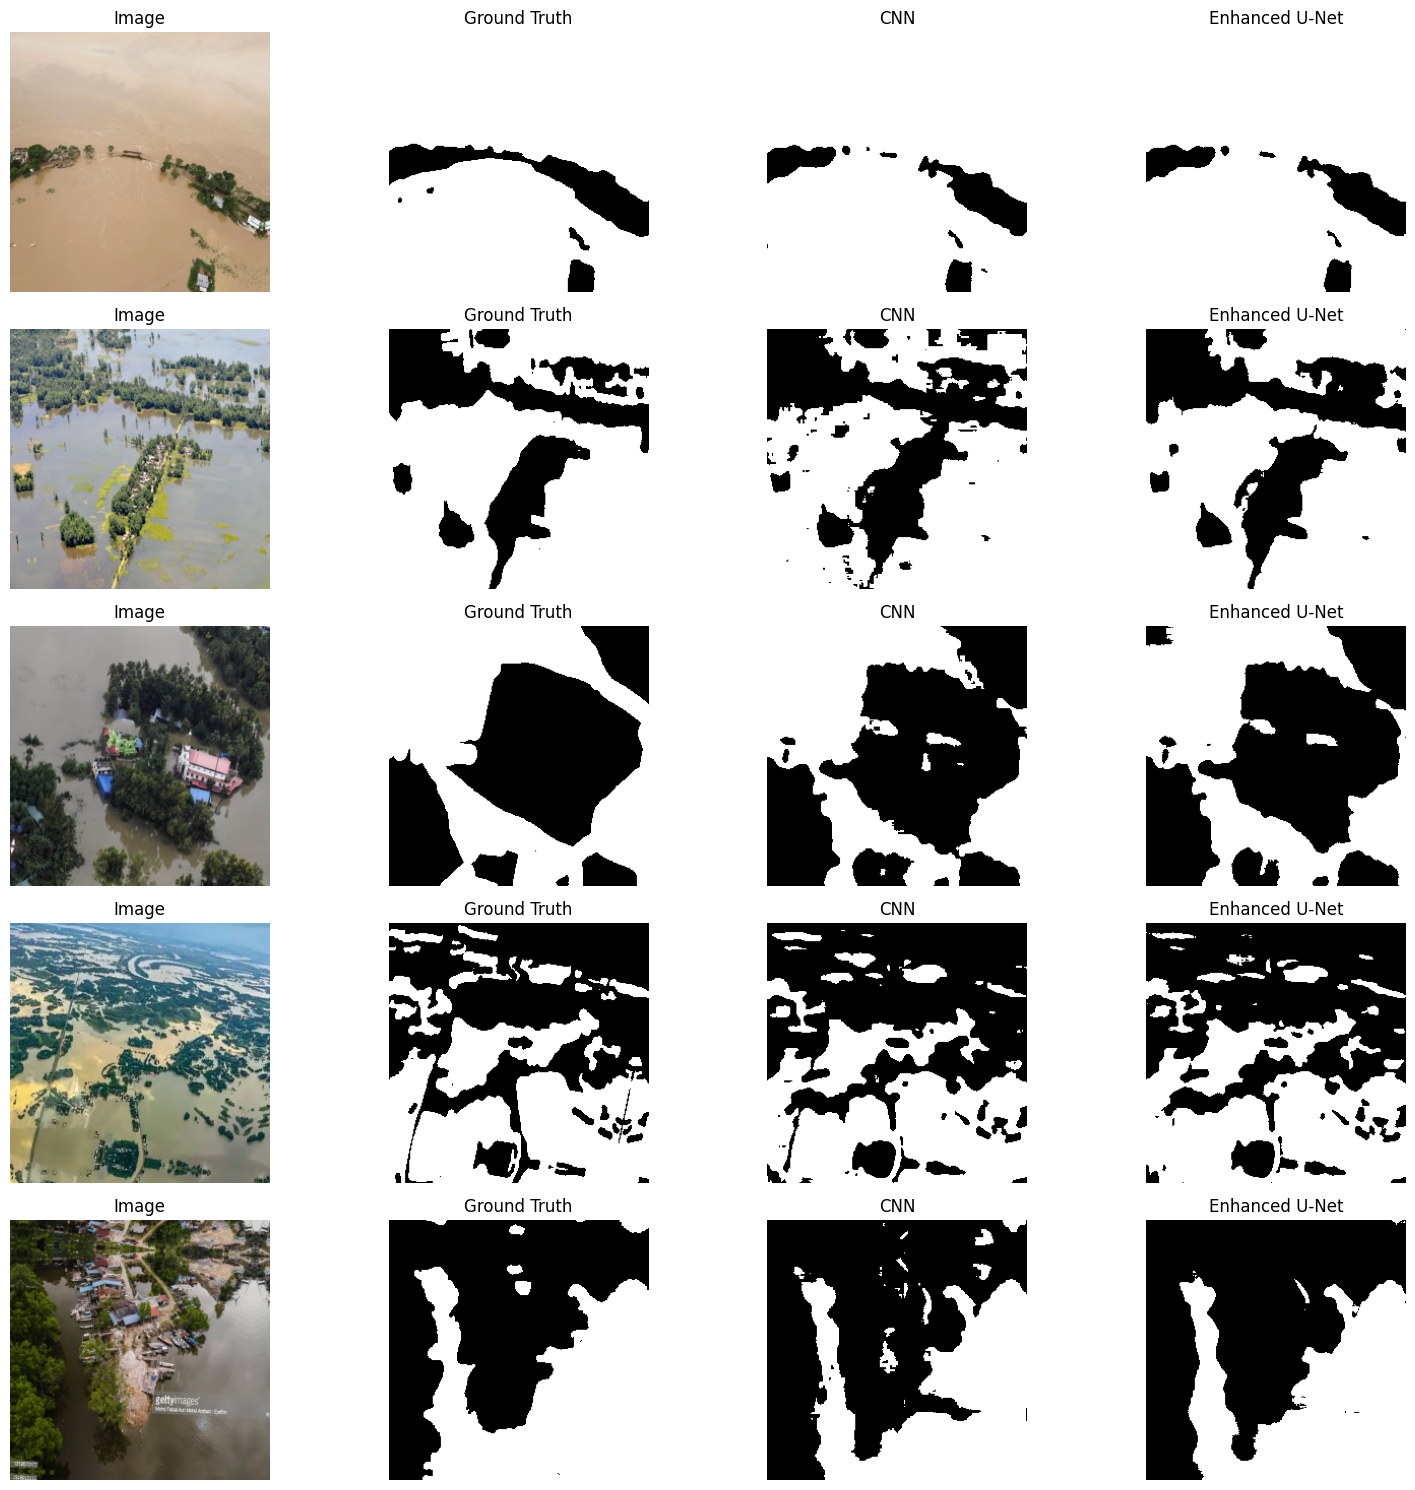

In [13]:
num_samples = 5

indices = np.random.choice(
    len(X_test),
    num_samples,
    replace=False
)

plt.figure(figsize=(16, num_samples*3))

for i, idx in enumerate(indices):

    image = X_test[idx]

    gt = Y_test[idx]

    cnn_pred = cnn_model.predict(
        image[np.newaxis],
        verbose=0
    )[0]

    cnn_pred = (cnn_pred > 0.5).astype(np.uint8)

    unet_pred = unet_model.predict(
        image[np.newaxis],
        verbose=0
    )[0]

    unet_pred = (unet_pred > 0.5).astype(np.uint8)

    plt.subplot(num_samples,4,4*i+1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(num_samples,4,4*i+2)
    plt.imshow(gt.squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(num_samples,4,4*i+3)
    plt.imshow(cnn_pred.squeeze(), cmap="gray")
    plt.title("CNN")
    plt.axis("off")

    plt.subplot(num_samples,4,4*i+4)
    plt.imshow(unet_pred.squeeze(), cmap="gray")
    plt.title("Enhanced U-Net")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
print("="*60)
print("FINAL COMPARISON")
print("="*60)

print(f"Basic CNN Accuracy      : {cnn_results['accuracy']:.4f}")
print(f"Enhanced U-Net Accuracy : {unet_results['accuracy']:.4f}")

print()

print(f"Basic CNN Dice          : {cnn_results['dice_coefficient']:.4f}")
print(f"Enhanced U-Net Dice     : {unet_results['dice_coefficient']:.4f}")

print()

print(f"Basic CNN IoU           : {cnn_results['iou_score']:.4f}")
print(f"Enhanced U-Net IoU      : {unet_results['iou_score']:.4f}")

print()

print(f"Basic CNN Loss          : {cnn_results['loss']:.4f}")
print(f"Enhanced U-Net Loss     : {unet_results['loss']:.4f}")

print("\nEnhanced U-Net outperformed the Basic CNN across all evaluation metrics and is selected as the final model.")

FINAL COMPARISON
Basic CNN Accuracy      : 0.8928
Enhanced U-Net Accuracy : 0.9233

Basic CNN Dice          : 0.8356
Enhanced U-Net Dice     : 0.8774

Basic CNN IoU           : 0.7178
Enhanced U-Net IoU      : 0.7817

Basic CNN Loss          : 0.4411
Enhanced U-Net Loss     : 0.3279

Enhanced U-Net outperformed the Basic CNN across all evaluation metrics and is selected as the final model.
